# Autoencoders for RNA-seq data

In this notebook we work with **high-dimensional data**, meaning we have many more features than samples. High dimensionality can be **challenging** because distances and similarities become less informative and models can **overfit** more easily (often summarized as the **curse of dimensionality**).

A common clinical data type with very high feature counts is sequencing data. In **RNA-seq**, each sample is represented by expression values for thousands of genes, so the input space is naturally large. Here we use an autoencoder to learn a **compact latent representation** of RNA-seq profiles that can be used for visualization and downstream analyses. The dataset we use for this is called CPTAC. CPTAC (the Clinical Proteomic Tumor Analysis Consortium) is an NCI-led effort that provides large, public multi-omics datasets from patient tumors, with matched clinical annotations.

Goal:
- Load bulk [RNA-seq](https://en.wikipedia.org/wiki/RNA-Seq) data from [CPTAC](https://www.cell.com/consortium/cptac) via the `cptac` Python package
- Train an autoencoder to compress high-dimensional gene expression into a low-dimensional latent space
- Visualize reconstruction loss and latent representations (PCA)

In [ ]:
from google.colab import ai
response = ai.generate_text("Tell me what AI you are and can you help me with coding problems?")
print(response)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

## 1) Load CPTAC dataset (RNA-seq)

We use the `cptac` package, which provides programmatic access to CPTAC cohorts as pandas DataFrames.

Notes:
- On first use, the dataset may download and cache locally (can take a bit, depending on cohort).
- CPTAC cohorts contain multiple omics layers; we focus on transcriptomics (RNA-seq).

In [ ]:
!pip install cptac # should take around 2-3 min
import cptac

Now, lets see what data we have available in this package.

In [ ]:
cptac.get_source_options()

## 2) Get RNA-seq matrix

CPTAC uses multiple data sources. Transcriptomics is typically available as a dataframe with gene expressions as columns and patients as rows.
We’ll:
- extract transcriptomics counts for several cancer types
- combine them into one big dataframe
- drop samples with missing values

In [ ]:
cohort_classes = [
    ("Brca", cptac.Brca),
    ("Ccrcc", cptac.Ccrcc),
    ("Colon", cptac.Coad),
    ("Gbm", cptac.Gbm),
    ("Luad", cptac.Luad),
    ("Ovarian", cptac.Ov),
    ("Pdac", cptac.Pdac),
    ("Ucec", cptac.Ucec),]

source = "bcm"

dfs = []
loaded = []

for name, cls in cohort_classes:
    cohort = cls()
    tx = cohort.get_transcriptomics(source)
    tx = tx.copy()
    tx["cancer_type"] = name
    dfs.append(tx)
    loaded.append((name, tx.shape))
    print(f"Loaded {name}: {tx.shape}")
print("\nLoaded cohorts:", loaded)

In [ ]:
dfs[0] # please have a look how many genes there are in this dataset

**Exercise 1:** We now have a list of dataframes in which columns are genes and rows are patient. We want to create a large dataframe from all of them. For this, we need to find which columns overlap between the dataframes, reduce the single dataframes just to these columns and append them. For convenience we delete all columns any NaNs in them (you can also fill them with 0s, the column mean, ...). Then we can split up the dataframes in data and label ("cancer_type"). You can use the AI or have a look at the [solutions.ipynb](https://colab.research.google.com/drive/1MrSwVSsGVpz5tbnYzv4suWuvDRgLiKO4#scrollTo=Ty59qLXhNpO1).

## 3) Train/validation split + scaling

Autoencoders are trained to reconstruct the input.
We scale features so training is stable:
- fit scaler on training set only
- apply to validation set

In [ ]:
y = labels_all.values # you can change labels_all to your variable that stores the labels

X = expr.values.astype(np.float32) # you can change expr to your variable that stores the data

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

train_ds = TensorDataset(torch.tensor(X_train_s), torch.tensor(X_train_s))
val_ds   = TensorDataset(torch.tensor(X_val_s), torch.tensor(X_val_s))
test_ds  = TensorDataset(torch.tensor(X_test_s), torch.tensor(X_test_s))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

input_dim = X_train_s.shape[1]
print("Input dim:", input_dim)
print("Train/Val/Test:", X_train_s.shape[0], X_val_s.shape[0], X_test_s.shape[0])

## 4) Define an autoencoder

An **autoencoder** is a neural network trained to **reconstruct its input**. It consists of an **encoder** that compresses the data into a **low-dimensional latent embedding**, and a **decoder** that reconstructs the original data from that embedding.

We use autoencoders to learn **compact representations** of high-dimensional data (e.g., gene expression) in an unsupervised way. The latent embeddings can then be used for visualization, clustering, denoising, or as features for downstream prediction models.

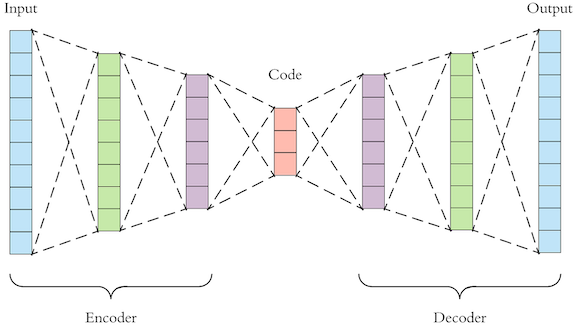

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim1=4096, hidden_dim2=1024, latent_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

In this case, our loss is the **Mean Squared Error (MSE)**. MSE is used when the model is predicting continuous-valued outputs, because it penalizes how far each predicted value is from the target value. In an autoencoder, the target is the original input vector itself (e.g., gene expression levels), so the decoder is doing regression of continuous features rather than predicting discrete class labels.

In [ ]:
device = torch.device("cuda")
print("Device:", device)

model = Autoencoder(input_dim=input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)


## 5) Training loop



**Exercise 2:** Please write the training loop method `run_epoch()`. You can have a look at previous examples. The method should set the model to training mode, load the data and labels to the GPU, set your optimizer, calculate the loss, do backtracking and make a step with the optimizer. Also check which input parameters are using in the loop below.

In [ ]:
num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    tr_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
    va_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
        print(f"Epoch {epoch:03d}/{num_epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

## 6) Plot reconstruction loss

**Exercise 3:** Make a graph about the training and validation loss over the epochs.

## 7) Extract latent space + PCA visualization

We encode samples into a latent vector `z` (e.g. 512 dims),
then project to 2D with PCA for visualization.

In [ ]:
@torch.no_grad()
def get_latent(model, X_scaled, device="cpu", batch_size=512):
    model.eval()
    zs = []
    loader = DataLoader(torch.tensor(X_scaled, dtype=torch.float32),
                        batch_size=batch_size, shuffle=False)
    for xb in loader:
        xb = xb.to(device)
        _, z = model(xb)
        zs.append(z.cpu())
    return torch.cat(zs, dim=0).numpy()

Z_test  = get_latent(model, X_test_s, device=device)

print("Z_train shape:", Z_test.shape)

**Exercise 4**: Plot a PCA of the laten features of the model. Color data points by cancer type.

**Exercise 5**: Plot a UMAP of the laten features of the model. Color data points by cancer type.